# Querying antigen-annotated T-cell receptors

This tutorial shows how to load Gene Expression, Antigen Capture (BEAM-T), TCR, and antigen-specificity score outputs from a public 10x Genomics dataset, combine the GEX and AIRR modalities in a {class}`~mudata.MuData` object, build a deterministic reference of EBV-associated receptors, and query the remaining query-suitable cells with {func}`scirpy.tl.ir_query`.

We use the public 10x Genomics **10k Human A1101 PBMCs with EBV Spike In (BEAM-T)** dataset, which contains human PBMCs, a `HLA-A*11:01`-restricted assay, and expanded anti-EBV T cells spiked into donor PBMCs. The assayed peptides are EBV `AVFDRKSDAK`, CMV `NLVPMVATV`, and a `HLA-A*11:01` negative-control peptide. The downloaded data yield EBV-assigned cells under the illustrative threshold used below, but no CMV-assigned cells.

The goal here is a **receptor-query workflow demonstration**, not an antigen-specificity benchmark. Exact receptor identity can support biological follow-up, but it does **not** prove antigen specificity, and cells below an illustrative BEAM score threshold are labeled **unassigned** rather than negative.

**Sources and attribution**

- [10x Genomics dataset page](https://www.10xgenomics.com/datasets/10k-human-a1101-pbmcs-with-ebv-spike-in-beam-t-2-standard)
- [Cell Ranger Antigen Capture algorithm](https://www.10xgenomics.com/support/software/cell-ranger/latest/algorithms-overview/cr-5p-antigen-algorithm)
- [Cell Ranger per-sample output tables](https://www.10xgenomics.com/support/software/cell-ranger/latest/analysis/outputs/cr-5p-outputs-per-sample-outs-multi)
- [10x Loupe worked example using an antigen specificity threshold of 90](https://www.10xgenomics.com/support/software/loupe-vdj-browser/latest/tutorials/lvb-integrated-analysis-loupe-browser)
- Dataset license: [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/)
- Scirpy functions used in this notebook are documented on the {doc}`../tutorials` page and in the API reference.


## Imports and settings

In [1]:
from __future__ import annotations

import hashlib
import json
import os
import warnings
from pathlib import Path

warnings.filterwarnings(
    "ignore",
    message=r"`__version__` is deprecated, use `importlib\.metadata\.version\('scanpy'\)` instead",
    category=FutureWarning,
)
warnings.filterwarnings(
    "ignore",
    message=r"Variable names are not unique.*",
    category=UserWarning,
)
warnings.filterwarnings(
    "ignore",
    message=r"Support for Awkward Arrays is currently experimental\. Behavior may change in the future\. Please report any issues you may encounter!",
)

import matplotlib.pyplot as plt
import muon as mu
import numpy as np
import pandas as pd
import pooch
import scanpy as sc
import scirpy as ir
from IPython.display import display

pooch.get_logger().setLevel("WARNING")

# Keep metadata explicit in the AIRR modality and avoid relying on MuData's legacy pull-on-update behavior.
mu.set_options(pull_on_update=False)

BEAM_SCORE_THRESHOLD = 90.0
CACHE_SUBDIR = "tutorial-beam-t-query"
DISTANCE_KEY = "ir_dist_beam_t_query_aa_identity"
QUERY_KEY = "ir_query_beam_t_query_aa_identity"
LABEL_ORDER = ["EBV", "CMV", "EBV+CMV", "unassigned", "ambiguous"]
CHAIN_PAIRING_ORDER = ["single pair", "extra VJ", "extra VDJ", "two full chains"]

FILE_SPECS = [
    {
        "logical_name": "gex_h5",
        "filename": "10k_BEAM-T_Human_A1101_EBV_spikein_5pv2_10k_BEAM-T_Human_A1101_EBV_spikein_5pv2_count_sample_filtered_feature_bc_matrix.h5",
        "url": "https://cf.10xgenomics.com/samples/cell-vdj/7.1.0/10k_BEAM-T_Human_A1101_EBV_spikein_5pv2_10k_BEAM-T_Human_A1101_EBV_spikein_5pv2/10k_BEAM-T_Human_A1101_EBV_spikein_5pv2_10k_BEAM-T_Human_A1101_EBV_spikein_5pv2_count_sample_filtered_feature_bc_matrix.h5",
        "sha256": "284b22a51ec6048d14ffd6f26db09e8769bd694623982e0e8aaa5bae69d38ed5",
        "size": 33707185,
    },
    {
        "logical_name": "vdj_csv",
        "filename": "10k_BEAM-T_Human_A1101_EBV_spikein_5pv2_10k_BEAM-T_Human_A1101_EBV_spikein_5pv2_vdj_t_filtered_contig_annotations.csv",
        "url": "https://cf.10xgenomics.com/samples/cell-vdj/7.1.0/10k_BEAM-T_Human_A1101_EBV_spikein_5pv2_10k_BEAM-T_Human_A1101_EBV_spikein_5pv2/10k_BEAM-T_Human_A1101_EBV_spikein_5pv2_10k_BEAM-T_Human_A1101_EBV_spikein_5pv2_vdj_t_filtered_contig_annotations.csv",
        "sha256": "3113306fa032e5b3d20d109557e04240d32c3903452d5ad154a940a68f120dca",
        "size": 7127144,
    },
    {
        "logical_name": "antigen_scores",
        "filename": "10k_BEAM-T_Human_A1101_EBV_spikein_5pv2_10k_BEAM-T_Human_A1101_EBV_spikein_5pv2_antigen_analysis_antigen_specificity_scores.csv",
        "url": "https://cf.10xgenomics.com/samples/cell-vdj/7.1.0/10k_BEAM-T_Human_A1101_EBV_spikein_5pv2_10k_BEAM-T_Human_A1101_EBV_spikein_5pv2/10k_BEAM-T_Human_A1101_EBV_spikein_5pv2_10k_BEAM-T_Human_A1101_EBV_spikein_5pv2_antigen_analysis_antigen_specificity_scores.csv",
        "sha256": "2b3302ac64bc6049d2117095c9dbd0d301d777ca30367b9d3fd96157720c6be0",
        "size": 1494338,
    },
    {
        "logical_name": "per_barcode",
        "filename": "10k_BEAM-T_Human_A1101_EBV_spikein_5pv2_10k_BEAM-T_Human_A1101_EBV_spikein_5pv2_antigen_analysis_per_barcode.csv",
        "url": "https://cf.10xgenomics.com/samples/cell-vdj/7.1.0/10k_BEAM-T_Human_A1101_EBV_spikein_5pv2_10k_BEAM-T_Human_A1101_EBV_spikein_5pv2/10k_BEAM-T_Human_A1101_EBV_spikein_5pv2_10k_BEAM-T_Human_A1101_EBV_spikein_5pv2_antigen_analysis_per_barcode.csv",
        "sha256": "c007f192d67b31521778de347c3a75b391d5559e08ae22df2acbcf8fb1d83a99",
        "size": 384186,
    },
]


In [2]:
def sha256_file(path: Path) -> str:
    hasher = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            hasher.update(chunk)
    return hasher.hexdigest()


def tutorial_cache_dir() -> Path:
    root = Path(os.environ.get("SCIRPY_DATA_DIR") or pooch.os_cache("scirpy"))
    cache_dir = root / CACHE_SUBDIR
    cache_dir.mkdir(parents=True, exist_ok=True)
    return cache_dir


def ensure_file(spec: dict[str, object], cache_dir: Path) -> Path:
    path = Path(
        pooch.retrieve(
            url=str(spec["url"]),
            known_hash=f"sha256:{spec['sha256']}",
            path=cache_dir,
            fname=str(spec["filename"]),
            progressbar=False,
        )
    )
    assert path.stat().st_size == spec["size"], f"Unexpected size for {path.name}"
    assert sha256_file(path) == spec["sha256"], f"Unexpected SHA-256 for {path.name}"
    return path


def assign_tutorial_label(df: pd.DataFrame, threshold: float = BEAM_SCORE_THRESHOLD) -> pd.Series:
    ebv = (df["EBV_score"] >= threshold) & (df["EBV_umi"] > 0)
    cmv = (df["CMV_score"] >= threshold) & (df["CMV_umi"] > 0)
    return pd.Series(
        np.select([ebv & ~cmv, cmv & ~ebv, ebv & cmv], ["EBV", "CMV", "EBV+CMV"], default="unassigned"),
        index=df.index,
        name="tutorial_label",
    )


def prepare_antigen_table(scores: pd.DataFrame, per_barcode: pd.DataFrame, gex_barcodes: pd.Index) -> pd.DataFrame:
    assert not scores.duplicated(["barcode", "antigen"]).any()
    assert set(scores["antigen"].unique()) == {"EBV", "CMV"}
    assert set(scores["control"].dropna().unique()) == {"negative_control"}
    assert set(scores["mhc_allele"].dropna().unique()) == {"HLA-A*11:01"}

    rows_per_barcode = scores.groupby("barcode").size()
    assert (rows_per_barcode == 2).all()
    antigen_sets = scores.groupby("barcode")["antigen"].agg(lambda values: tuple(sorted(values)))
    assert set(antigen_sets.unique()) == {("CMV", "EBV")}

    wide = scores.pivot(index="barcode", columns="antigen", values=["antigen_specificity_score", "antigen_umi", "control_umi"])
    assert len(wide) == 9798
    wide.columns = [f"{antigen}_{field}" for field, antigen in wide.columns]

    control_equal = wide["EBV_control_umi"].eq(wide["CMV_control_umi"])
    assert control_equal.all()

    scalar_cols = scores.groupby("barcode", as_index=True).agg(
        raw_clonotype_id=("raw_clonotype_id", "first"),
        exact_subclonotype_id=("exact_subclonotype_id", "first"),
    )

    antigen_table = (
        wide.join(scalar_cols, how="inner")
        .rename(
            columns={
                "EBV_antigen_specificity_score": "EBV_score",
                "CMV_antigen_specificity_score": "CMV_score",
                "EBV_antigen_umi": "EBV_umi",
                "CMV_antigen_umi": "CMV_umi",
            }
        )
        .assign(negative_control_umi=lambda df: df["EBV_control_umi"])
        .drop(columns=["EBV_control_umi", "CMV_control_umi"])
        .reset_index()
    )
    assert antigen_table["barcode"].nunique() == 9798

    assert not per_barcode["barcode"].duplicated().any()
    merged = antigen_table.merge(
        per_barcode[["barcode", "raw_clonotype_id", "exact_subclonotype_id"]].rename(
            columns={
                "raw_clonotype_id": "raw_clonotype_id_per_barcode",
                "exact_subclonotype_id": "exact_subclonotype_id_per_barcode",
            }
        ),
        on="barcode",
        how="inner",
        validate="one_to_one",
    )
    assert merged["barcode"].nunique() == 9798
    assert set(merged["barcode"]) == set(gex_barcodes)
    assert merged["raw_clonotype_id"].astype("string").fillna("<NA>").equals(
        merged["raw_clonotype_id_per_barcode"].astype("string").fillna("<NA>")
    )
    assert merged["exact_subclonotype_id"].astype("string").fillna("<NA>").equals(
        merged["exact_subclonotype_id_per_barcode"].astype("string").fillna("<NA>")
    )

    result = merged[[
        "barcode",
        "EBV_score",
        "CMV_score",
        "EBV_umi",
        "CMV_umi",
        "negative_control_umi",
        "raw_clonotype_id",
        "exact_subclonotype_id",
    ]].copy()
    result["tutorial_label"] = assign_tutorial_label(result)
    return result


def add_airr_obs_columns(mdata: mu.MuData, obs_df: pd.DataFrame) -> None:
    aligned = obs_df.set_index("barcode")
    for column in aligned.columns:
        mdata.mod["airr"].obs[column] = aligned[column].reindex(mdata.mod["airr"].obs_names)


def threshold_sensitivity_table(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for threshold in [50.0, 90.0, 92.5]:
        labels = assign_tutorial_label(df, threshold=threshold)
        counts = labels.value_counts().reindex(["EBV", "CMV", "EBV+CMV", "unassigned"], fill_value=0)
        rows.append({"threshold": threshold, **counts.to_dict()})
    return pd.DataFrame(rows)


def exact_primary_receptor_key(adata_airr) -> pd.DataFrame:
    fields = {}
    for chain in ["VJ_1", "VDJ_1"]:
        for field in ["junction_aa", "locus", "productive"]:
            fields[f"{chain}_{field}"] = ir.get.airr(adata_airr, field, chain)
    receptor_df = pd.DataFrame(fields, index=adata_airr.obs_names)
    receptor_df["query_suitable"] = (
        receptor_df["VJ_1_productive"].fillna(False)
        & receptor_df["VDJ_1_productive"].fillna(False)
        & receptor_df["VJ_1_locus"].eq("TRA")
        & receptor_df["VDJ_1_locus"].eq("TRB")
        & receptor_df["VJ_1_junction_aa"].notna()
        & receptor_df["VDJ_1_junction_aa"].notna()
    )
    receptor_df["exact_primary_receptor_key"] = receptor_df.apply(
        lambda row: json.dumps(
            {
                "VJ_1": {
                    "locus": None if pd.isna(row["VJ_1_locus"]) else str(row["VJ_1_locus"]),
                    "junction_aa": None if pd.isna(row["VJ_1_junction_aa"]) else str(row["VJ_1_junction_aa"]),
                },
                "VDJ_1": {
                    "locus": None if pd.isna(row["VDJ_1_locus"]) else str(row["VDJ_1_locus"]),
                    "junction_aa": None if pd.isna(row["VDJ_1_junction_aa"]) else str(row["VDJ_1_junction_aa"]),
                },
            },
            sort_keys=True,
        ),
        axis=1,
    )
    return receptor_df


def ecdf_xy(values: pd.Series) -> tuple[np.ndarray, np.ndarray]:
    clean = np.sort(values.dropna().to_numpy(dtype=float))
    if clean.size == 0:
        return np.array([]), np.array([])
    return clean, np.arange(1, clean.size + 1, dtype=float) / clean.size


def build_match_summary(pairs: pd.DataFrame) -> pd.DataFrame:
    if pairs.empty:
        return pd.DataFrame(columns=["tutorial_label", "tutorial_label_ref", "match_pair_count", "reference_barcode_count"])

    def unique_or_ambiguous(values: pd.Series) -> str | None:
        unique_values = pd.unique(values.dropna())
        if len(unique_values) == 0:
            return None
        if len(unique_values) == 1:
            return str(unique_values[0])
        return "ambiguous"

    return pairs.groupby("query_barcode").agg(
        tutorial_label=("tutorial_label", unique_or_ambiguous),
        tutorial_label_ref=("tutorial_label_ref", unique_or_ambiguous),
        match_pair_count=("reference_barcode", "size"),
        reference_barcode_count=("reference_barcode", "nunique"),
    )


## Retrieve the processed data

In [3]:
cache_dir = tutorial_cache_dir()
paths = {spec["logical_name"]: ensure_file(spec, cache_dir) for spec in FILE_SPECS}

file_table = pd.DataFrame(
    [
        {
            "logical name": spec["logical_name"],
            "local filename": paths[spec["logical_name"]].name,
            "file size": paths[spec["logical_name"]].stat().st_size,
        }
        for spec in FILE_SPECS
    ]
)
display(file_table)

,logical name,local filename,file size
0,gex_h5,10k_BEAM-T_Human_A1101_EBV_spikein_5pv2_10k_BE...,33707185
1,vdj_csv,10k_BEAM-T_Human_A1101_EBV_spikein_5pv2_10k_BE...,7127144
2,antigen_scores,10k_BEAM-T_Human_A1101_EBV_spikein_5pv2_10k_BE...,1494338
3,per_barcode,10k_BEAM-T_Human_A1101_EBV_spikein_5pv2_10k_BE...,384186


## Load GEX, Antigen Capture, and TCR data

In [4]:
adata_gex = sc.read_10x_h5(paths["gex_h5"], gex_only=False)
assert adata_gex.shape == (9798, 36604)

antigen_names_before = adata_gex.var_names[adata_gex.var["feature_types"].eq("Antigen Capture")].tolist()
assert antigen_names_before == ["EBV", "CMV", "negative_control"]

adata_gex.var_names_make_unique()

antigen_names_after = adata_gex.var_names[adata_gex.var["feature_types"].eq("Antigen Capture")].tolist()
assert antigen_names_after == ["EBV", "CMV", "negative_control"]
assert not adata_gex.var_names.duplicated().any()

adata_airr = ir.io.read_10x_vdj(paths["vdj_csv"])
mdata = mu.MuData({"gex": adata_gex, "airr": adata_airr})

feature_name_check = pd.DataFrame(
    {
        "before var_names_make_unique": antigen_names_before,
        "after var_names_make_unique": antigen_names_after,
    }
)
modality_counts = pd.DataFrame(
    {
        "cells": [mdata.mod["gex"].n_obs, mdata.mod["airr"].n_obs],
    },
    index=["gex", "airr"],
)

display(feature_name_check)
display(modality_counts)

,before var_names_make_unique,after var_names_make_unique
0,EBV,EBV
1,CMV,CMV
2,negative_control,negative_control


,cells
gex,9798
airr,5643


The Gene Expression and AIRR modalities do not contain exactly the same barcodes: the GEX matrix contains all 9,798 detected cells, whereas the TCR modality contains the 5,643 barcodes with TCR contigs.

## Prepare antigen metadata

The `antigen_analysis_per_barcode.csv` file is used here only as a barcode-level integrity check before we transfer the antigen labels onto AIRR cells.


In [5]:
scores = pd.read_csv(paths["antigen_scores"])
per_barcode = pd.read_csv(paths["per_barcode"])

antigen_table = prepare_antigen_table(scores, per_barcode, adata_gex.obs_names)
add_airr_obs_columns(mdata, antigen_table)

label_counts = (
    antigen_table["tutorial_label"]
    .value_counts()
    .reindex(["EBV", "CMV", "EBV+CMV", "unassigned"], fill_value=0)
    .rename_axis("tutorial label")
    .to_frame("cells")
)
display(label_counts)

,cells
tutorial label,
EBV,1147
CMV,0
EBV+CMV,0
unassigned,8651


## Define the illustrative BEAM label

Cell Ranger reports a continuous antigen-specificity score derived from antigen and negative-control UMI measurements. The score is **not** a direct measure of affinity or avidity.

We use a threshold of **90** for this tutorial because it appears in an official 10x worked example. It is an **illustrative analysis choice** rather than a universal cutoff, and 10x explicitly notes that the threshold should be adjusted to the sample type, antigens, experimental design, and scientific question.

Cells below this threshold are labeled **unassigned** rather than negative, because this tutorial does not establish that they lack antigen recognition.


In [6]:
sensitivity_table = threshold_sensitivity_table(antigen_table)
display(sensitivity_table)

,threshold,EBV,CMV,EBV+CMV,unassigned
0,50.0,1157,0,0,8641
1,90.0,1147,0,0,8651
2,92.5,1144,0,0,8654


## Visualize antigen-score distributions

The first plot compares the full EBV and CMV score distributions with an illustrative threshold line at 90. CMV is shown as an **assayed comparator**, not as the negative-control feature. In this dataset the CMV score distribution remains near zero, so no cells are assigned to CMV under the illustrative rule used here.


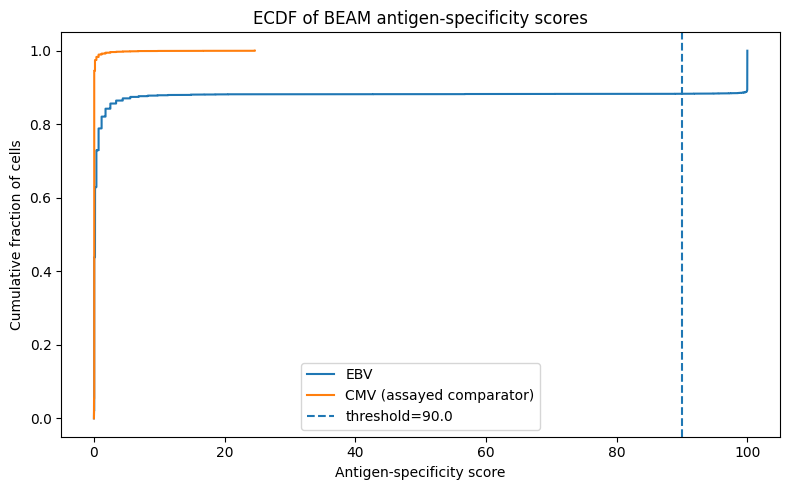

In [7]:
plt.figure(figsize=(8, 5))
for values, label in [
    (antigen_table["EBV_score"], "EBV"),
    (antigen_table["CMV_score"], "CMV (assayed comparator)"),
]:
    x, y = ecdf_xy(values)
    plt.step(x, y, where="post", label=label)
plt.axvline(BEAM_SCORE_THRESHOLD, linestyle="--", label=f"threshold={BEAM_SCORE_THRESHOLD}")
plt.title("ECDF of BEAM antigen-specificity scores")
plt.xlabel("Antigen-specificity score")
plt.ylabel("Cumulative fraction of cells")
plt.legend()
plt.tight_layout()

## Index receptor chains and run QC

We now apply Scirpy's receptor model explicitly with {func}`scirpy.pp.index_chains` followed by {func}`scirpy.tl.chain_qc`. With the default settings, chain indexing keeps productive chains with amino-acid junction sequences.

For this tutorial, **query-suitable cells** are cells with a productive **primary** `TRA`/`TRB` pair after Scirpy chain indexing. This includes cells with additional secondary chains, so it is broader than the `single pair` category alone.


In [8]:
ir.pp.index_chains(mdata)
ir.tl.chain_qc(mdata)

receptor_df = exact_primary_receptor_key(mdata.mod["airr"])
for column in receptor_df.columns:
    mdata.mod["airr"].obs[column] = receptor_df[column]
mdata.mod["airr"].obs["barcode"] = mdata.mod["airr"].obs_names.astype(str)

query_suitable_mask = mdata.mod["airr"].obs["query_suitable"].fillna(False)
query_suitable_df = mdata.mod["airr"].obs.loc[query_suitable_mask].copy()

chain_pairing_counts = (
    query_suitable_df["chain_pairing"]
    .value_counts()
    .reindex(CHAIN_PAIRING_ORDER, fill_value=0)
    .rename_axis("chain pairing")
    .to_frame("cells")
)
count_summary = pd.DataFrame(
    {
        "cells": [mdata.mod["gex"].n_obs, mdata.mod["airr"].n_obs, int(query_suitable_mask.sum())],
    },
    index=["GEX", "AIRR", "query-suitable AIRR"],
)

display(count_summary)
display(chain_pairing_counts)

,cells
GEX,9798
AIRR,5643
query-suitable AIRR,5078


,cells
chain pairing,
single pair,4310
extra VJ,526
extra VDJ,123
two full chains,119


## Construct exact paired-receptor keys

To match the Scirpy query settings used below, the tutorial key keeps only the **primary** `VJ` and `VDJ` loci plus their amino-acid junction sequences. We intentionally do **not** include V or J gene calls because the query step uses `same_v_gene=False`.


In [9]:
query_suitable_label_counts = (
    query_suitable_df["tutorial_label"]
    .value_counts()
    .reindex(["EBV", "CMV", "EBV+CMV", "unassigned"], fill_value=0)
    .rename_axis("tutorial label")
    .to_frame("query-suitable cells")
)
key_summary = pd.DataFrame(
    {
        "value": [
            query_suitable_df["exact_primary_receptor_key"].nunique(),
            int((query_suitable_df["chain_pairing"] != "single pair").sum()),
        ]
    },
    index=["unique exact primary paired receptors", "query-suitable cells with extra chains"],
)

display(query_suitable_label_counts)
display(key_summary)

,query-suitable cells
tutorial label,
EBV,362
CMV,0
EBV+CMV,0
unassigned,4716


,value
unique exact primary paired receptors,4497
query-suitable cells with extra chains,768


## Build the reference and query datasets

Reference candidates are the query-suitable cells labeled `EBV`. For each exact paired-receptor group, we select the **lexicographically smallest barcode** as a deterministic representative. The selected cell is a deterministic representative of its receptor group and is **not** treated as the biologically canonical cell for that receptor.


In [10]:
reference_candidates = query_suitable_df.loc[query_suitable_df["tutorial_label"].eq("EBV")].copy()
reference_candidates["barcode"] = reference_candidates.index.astype(str)
reference_candidates = reference_candidates.sort_values(["exact_primary_receptor_key", "barcode"])
reference_obs = reference_candidates.drop_duplicates("exact_primary_receptor_key", keep="first").copy()

assert reference_obs["tutorial_label"].eq("EBV").all()
assert not reference_obs["exact_primary_receptor_key"].duplicated().any()

reference_barcodes = reference_obs.index.tolist()
query_barcodes = [barcode for barcode in query_suitable_df.index if barcode not in set(reference_barcodes)]

assert set(reference_barcodes).isdisjoint(query_barcodes)
assert reference_barcodes
assert query_barcodes

reference = mdata[reference_barcodes, :].copy()
query = mdata[query_barcodes, :].copy()

reference_query_table = pd.DataFrame(
    {
        "cells": [reference.n_obs, reference.mod["airr"].obs["exact_primary_receptor_key"].nunique(), query.n_obs],
    },
    index=["reference cells", "unique reference receptors", "query cells"],
)
display(reference_query_table)

,cells
reference cells,110
unique reference receptors,110
query cells,4968


## Query the reference receptors

In [11]:
ir.pp.ir_dist(query, reference, sequence="aa", metric="identity", cutoff=0, key_added=DISTANCE_KEY)
ir.tl.ir_query(
    query,
    reference,
    sequence="aa",
    metric="identity",
    receptor_arms="all",
    dual_ir="primary_only",
    same_v_gene=False,
    match_columns=None,
    distance_key=DISTANCE_KEY,
    key_added=QUERY_KEY,
)

pairs = (
    ir.tl.ir_query_annotate_df(
        query,
        reference,
        sequence="aa",
        metric="identity",
        include_query_cols=[
            "tutorial_label",
            "EBV_score",
            "CMV_score",
            "EBV_umi",
            "CMV_umi",
            "negative_control_umi",
            "exact_primary_receptor_key",
            "barcode",
        ],
        include_ref_cols=[
            "tutorial_label",
            "EBV_score",
            "CMV_score",
            "EBV_umi",
            "CMV_umi",
            "negative_control_umi",
            "exact_primary_receptor_key",
            "barcode",
        ],
        suffix="_ref",
        query_key=QUERY_KEY,
    )
    .rename_axis("query_barcode")
    .reset_index()
    .rename(columns={"barcode": "query_barcode_obs", "barcode_ref": "reference_barcode"})
)

assert pairs["exact_primary_receptor_key"].eq(pairs["exact_primary_receptor_key_ref"]).all()

match_preview = pairs[[
    "query_barcode",
    "reference_barcode",
    "tutorial_label",
    "tutorial_label_ref",
    "EBV_score",
    "CMV_score",
    "EBV_umi",
    "CMV_umi",
    "negative_control_umi",
]].sort_values(["tutorial_label", "query_barcode", "reference_barcode"]).head(10)

display(match_preview)


,query_barcode,reference_barcode,tutorial_label,tutorial_label_ref,EBV_score,CMV_score,EBV_umi,CMV_umi,negative_control_umi
2,AACGTTGGTCACCTAA-1,AACACGTCAGTAAGCG-1,EBV,EBV,100.000,0.042,318.0,0.0,0.0
4,AACTCAGGTAAACGCG-1,AACACGTCAGTAAGCG-1,EBV,EBV,100.000,0.000,317.0,0.0,2.0
5,AAGCCGCGTGCGGTAA-1,AACACGTCAGTAAGCG-1,EBV,EBV,100.000,0.042,416.0,0.0,0.0
7,AATCCAGTCATATCGG-1,AACACGTCAGTAAGCG-1,EBV,EBV,100.000,0.042,443.0,0.0,0.0
9,ACACCAAAGTACATGA-1,AACACGTCAGTAAGCG-1,EBV,EBV,100.000,0.060,468.0,14.0,4.0
10,ACACTGAAGGTCATCT-1,ACACCGGGTTGAGGTG-1,EBV,EBV,100.000,0.003,422.0,0.0,1.0
12,ACATACGTCAAACGGG-1,AACACGTCAGTAAGCG-1,EBV,EBV,100.000,0.000,731.0,2.0,3.0
13,ACCAGTAAGGCGATAC-1,AACTTTCTCTCCCTGA-1,EBV,EBV,100.000,0.042,653.0,0.0,0.0
14,ACCGTAAGTCCAGTAT-1,ACACCGGGTTGAGGTG-1,EBV,EBV,100.000,0.042,506.0,0.0,0.0
17,ACGAGCCTCGGTCCGA-1,AACACGTCAGTAAGCG-1,EBV,EBV,99.999,4.144,269.0,21.0,2.0


## Summarize query results

{func}`scirpy.tl.ir_query_annotate_df` returns all query/reference pairs, so we count **match pairs** separately from **unique matched query cells**. A future run with different parameters could return more than one reference match per query cell, even though this exact-identity example does not.


In [12]:
match_summary = build_match_summary(pairs)
match_pair_count = len(pairs)
unique_matched_query_cells = len(match_summary)
multiple_reference_matches = int((match_summary["reference_barcode_count"] > 1).sum()) if len(match_summary) else 0
unmatched_query_cells = query.n_obs - unique_matched_query_cells

summary_table = pd.DataFrame(
    {
        "value": [
            reference.n_obs,
            reference.mod["airr"].obs["exact_primary_receptor_key"].nunique(),
            query.n_obs,
            match_pair_count,
            unique_matched_query_cells,
            unmatched_query_cells,
            multiple_reference_matches,
        ]
    },
    index=[
        "reference cells",
        "unique reference receptors",
        "query cells",
        "match pairs",
        "unique matched query cells",
        "unmatched query cells",
        "query cells with multiple reference matches",
    ],
)

label_table = (
    pd.crosstab(match_summary["tutorial_label_ref"], match_summary["tutorial_label"], dropna=False)
    .reindex(index=LABEL_ORDER, columns=LABEL_ORDER, fill_value=0)
    .rename_axis(index="reference tutorial label", columns="matched query cell by its own BEAM assignment")
)

display(summary_table)
display(label_table)

,value
reference cells,110
unique reference receptors,110
query cells,4968
match pairs,357
unique matched query cells,357
unmatched query cells,4611
query cells with multiple reference matches,0


matched query cell by its own BEAM assignment,EBV,CMV,EBV+CMV,unassigned,ambiguous
reference tutorial label,,,,,
EBV,252,0,0,105,0
CMV,0,0,0,0,0
EBV+CMV,0,0,0,0,0
unassigned,0,0,0,0,0
ambiguous,0,0,0,0,0


Exact receptor groups can span both sides of the illustrative threshold. In this dataset, some query cells with exact receptor matches to EBV-assigned reference cells are themselves `unassigned` by their per-cell BEAM score.


## Visualize scores among query-result groups

The second ECDF uses **unique query cells only** and compares three groups: matched `EBV` query cells, matched `unassigned` query cells, and unmatched query cells. Reference cells are excluded.

Exact receptor matches can appear in both EBV-assigned and unassigned cells because the BEAM score is measured per cell. This tutorial does not determine why those per-cell scores differ.


,cells,median EBV score
matched EBV-assigned query cells,252,100.000
matched unassigned query cells,105,0.042
unmatched query cells,4611,0.042


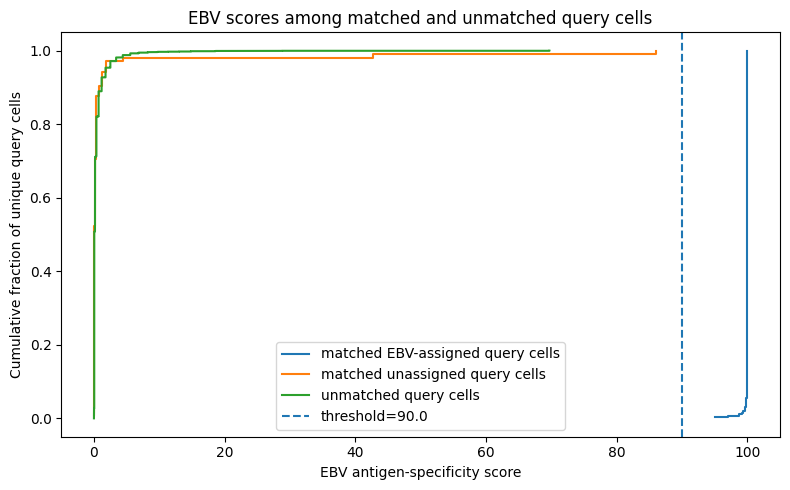

In [13]:
matched_ebv_barcodes = match_summary.index[match_summary["tutorial_label"].eq("EBV")]
matched_unassigned_barcodes = match_summary.index[match_summary["tutorial_label"].eq("unassigned")]
matched_query_barcodes = set(match_summary.index)

query_airr_obs = query.mod["airr"].obs
matched_ebv_query = query_airr_obs.loc[matched_ebv_barcodes]
matched_unassigned_query = query_airr_obs.loc[matched_unassigned_barcodes]
unmatched_query = query_airr_obs.loc[~query_airr_obs.index.isin(matched_query_barcodes)]

plt.figure(figsize=(8, 5))
for label, values in [
    ("matched EBV-assigned query cells", matched_ebv_query["EBV_score"]),
    ("matched unassigned query cells", matched_unassigned_query["EBV_score"]),
    ("unmatched query cells", unmatched_query["EBV_score"]),
]:
    x, y = ecdf_xy(values)
    plt.step(x, y, where="post", label=label)
plt.axvline(BEAM_SCORE_THRESHOLD, linestyle="--", label=f"threshold={BEAM_SCORE_THRESHOLD}")
plt.title("EBV scores among matched and unmatched query cells")
plt.xlabel("EBV antigen-specificity score")
plt.ylabel("Cumulative fraction of unique query cells")
plt.legend()
plt.tight_layout()

score_group_table = pd.DataFrame(
    {
        "cells": [len(matched_ebv_query), len(matched_unassigned_query), len(unmatched_query)],
        "median EBV score": [
            matched_ebv_query["EBV_score"].median(),
            matched_unassigned_query["EBV_score"].median(),
            unmatched_query["EBV_score"].median(),
        ],
    },
    index=["matched EBV-assigned query cells", "matched unassigned query cells", "unmatched query cells"],
)
display(score_group_table)

## Interpretation and limitations

- The threshold of 90 is illustrative and dataset-specific.
- `unassigned` does not mean antigen negative.
- CMV is an assayed comparator, not the negative-control feature.
- This dataset contains an EBV-specific spike-in.
- Exact receptor identity does not prove antigen specificity.
- Identical receptors can occur in cells with different per-cell BEAM scores.
- The selected reference cell is only a deterministic representative.
- This tutorial demonstrates receptor querying, not predictive validation.
- The internal reference/query construction intentionally allows receptor groups to appear in both sets.
- No sensitivity, specificity, or predictive accuracy is estimated.
